In [1]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc
from scanpy import AnnData
sc.set_figure_params(figsize=(4,4))
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype']=42
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scanpy import AnnData

In [2]:
adata=sc.read_h5ad('joint_281146.h5ad')

In [3]:
meta=pd.read_csv('metadata_passQC_05212026.tsv.gz',sep='\t').set_index('ID')
for c in meta.columns:
    adata.obs[c]=meta[c]

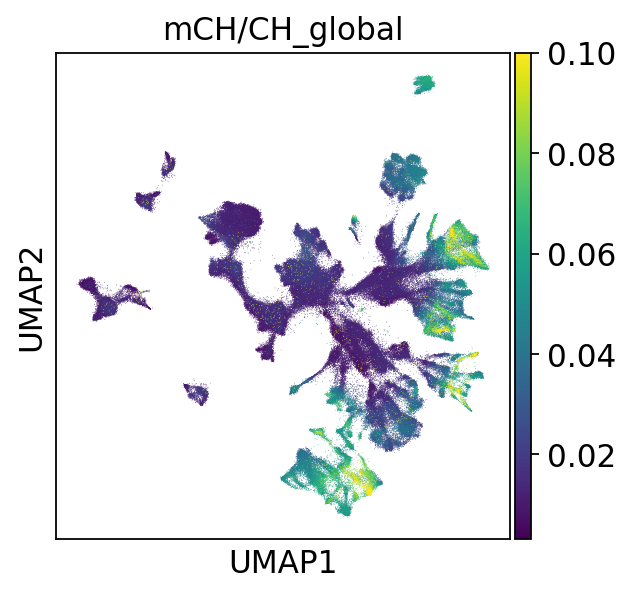

In [4]:
sc.pl.umap(adata,color='mCH/CH_global',vmax=.1)

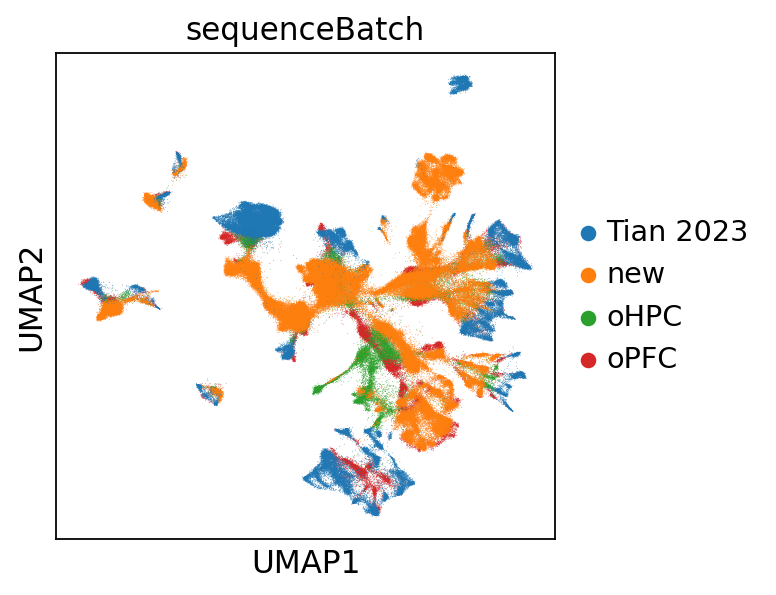

In [5]:
sc.pl.umap(adata,color='sequenceBatch',palette=sc.pl.palettes.vega_10)

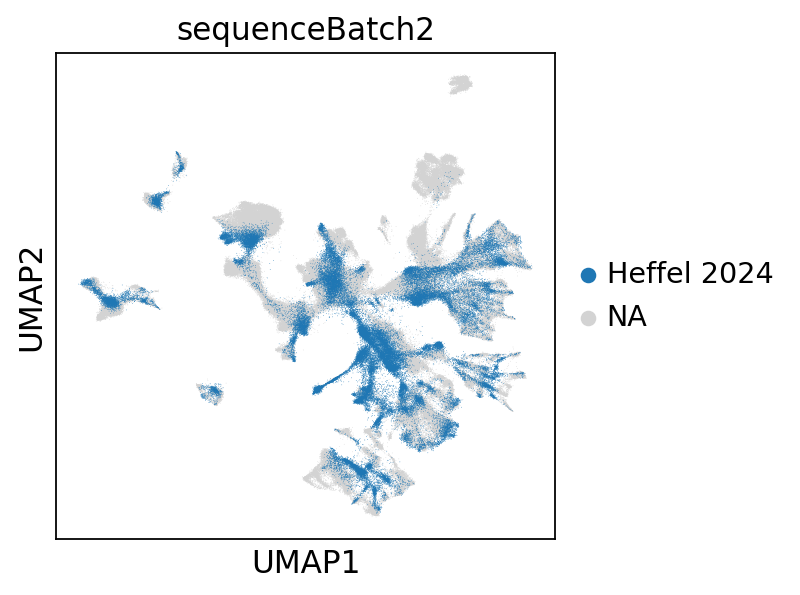

In [6]:
sc.pl.umap(adata,color='sequenceBatch2',groups=['Heffel 2024'],palette=[sc.pl.palettes.vega_10[0]])

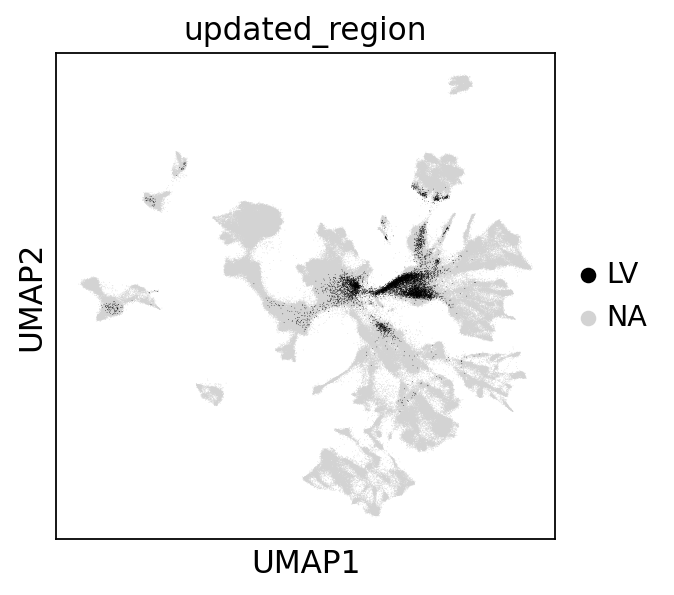

In [7]:
sc.pl.umap(adata,color='updated_region',groups=['LV'],palette=['black'])

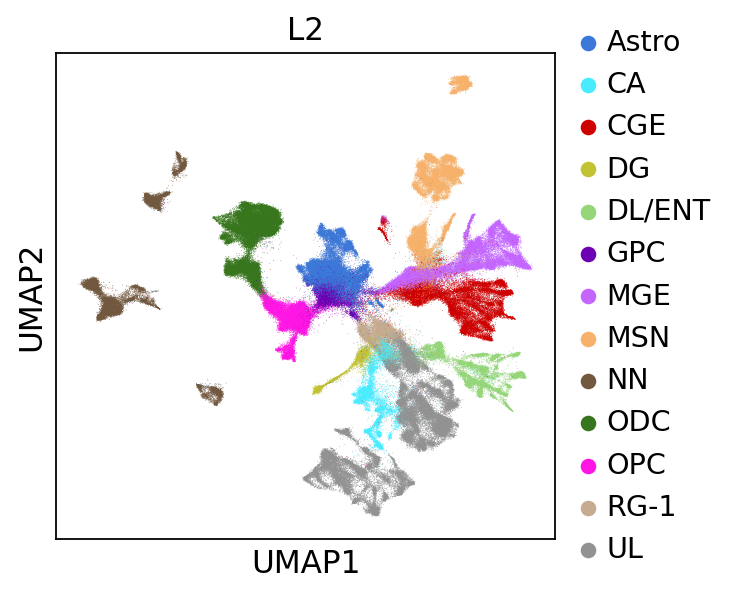

In [8]:
adata.uns['L2_colors']=['#3c78d8', '#49ecff', '#ce0000', '#c2c234', '#94d678',
                           '#6e00b3', '#c465ff', '#f6b26b', '#72583e', '#38761d',
                           '#ff16e4', '#c5ab90', '#929292']
sc.pl.umap(adata,color='L2',save='newL2.pdf')

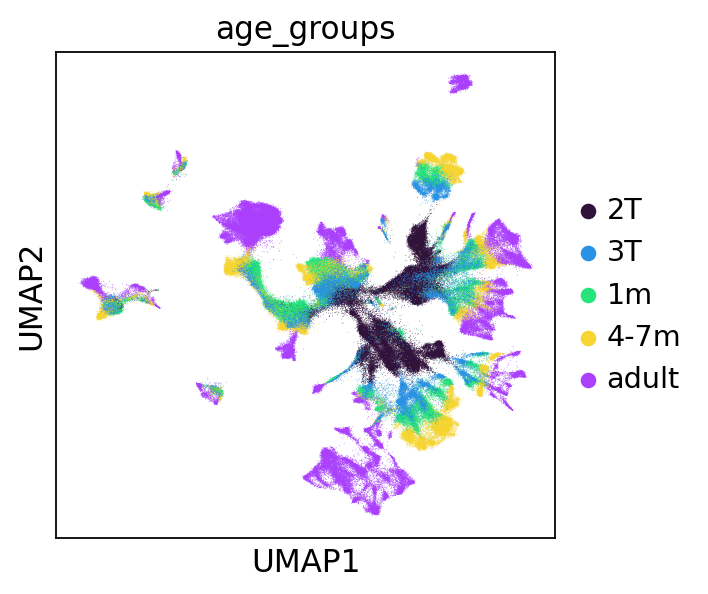

In [9]:
category_order = ['2T', '3T', '1m', '4-7m', 'adult']
adata.obs['age_groups'] = pd.Categorical(adata.obs['age_groups'], categories=category_order, ordered=True)

# Plot UMAP with the specified category order
sc.pl.umap(adata, color='age_groups',palette=['#30123b', '#2a92e5', '#27e37b', '#f6d531', '#aa40fc'],
          save='age_groups.pdf')

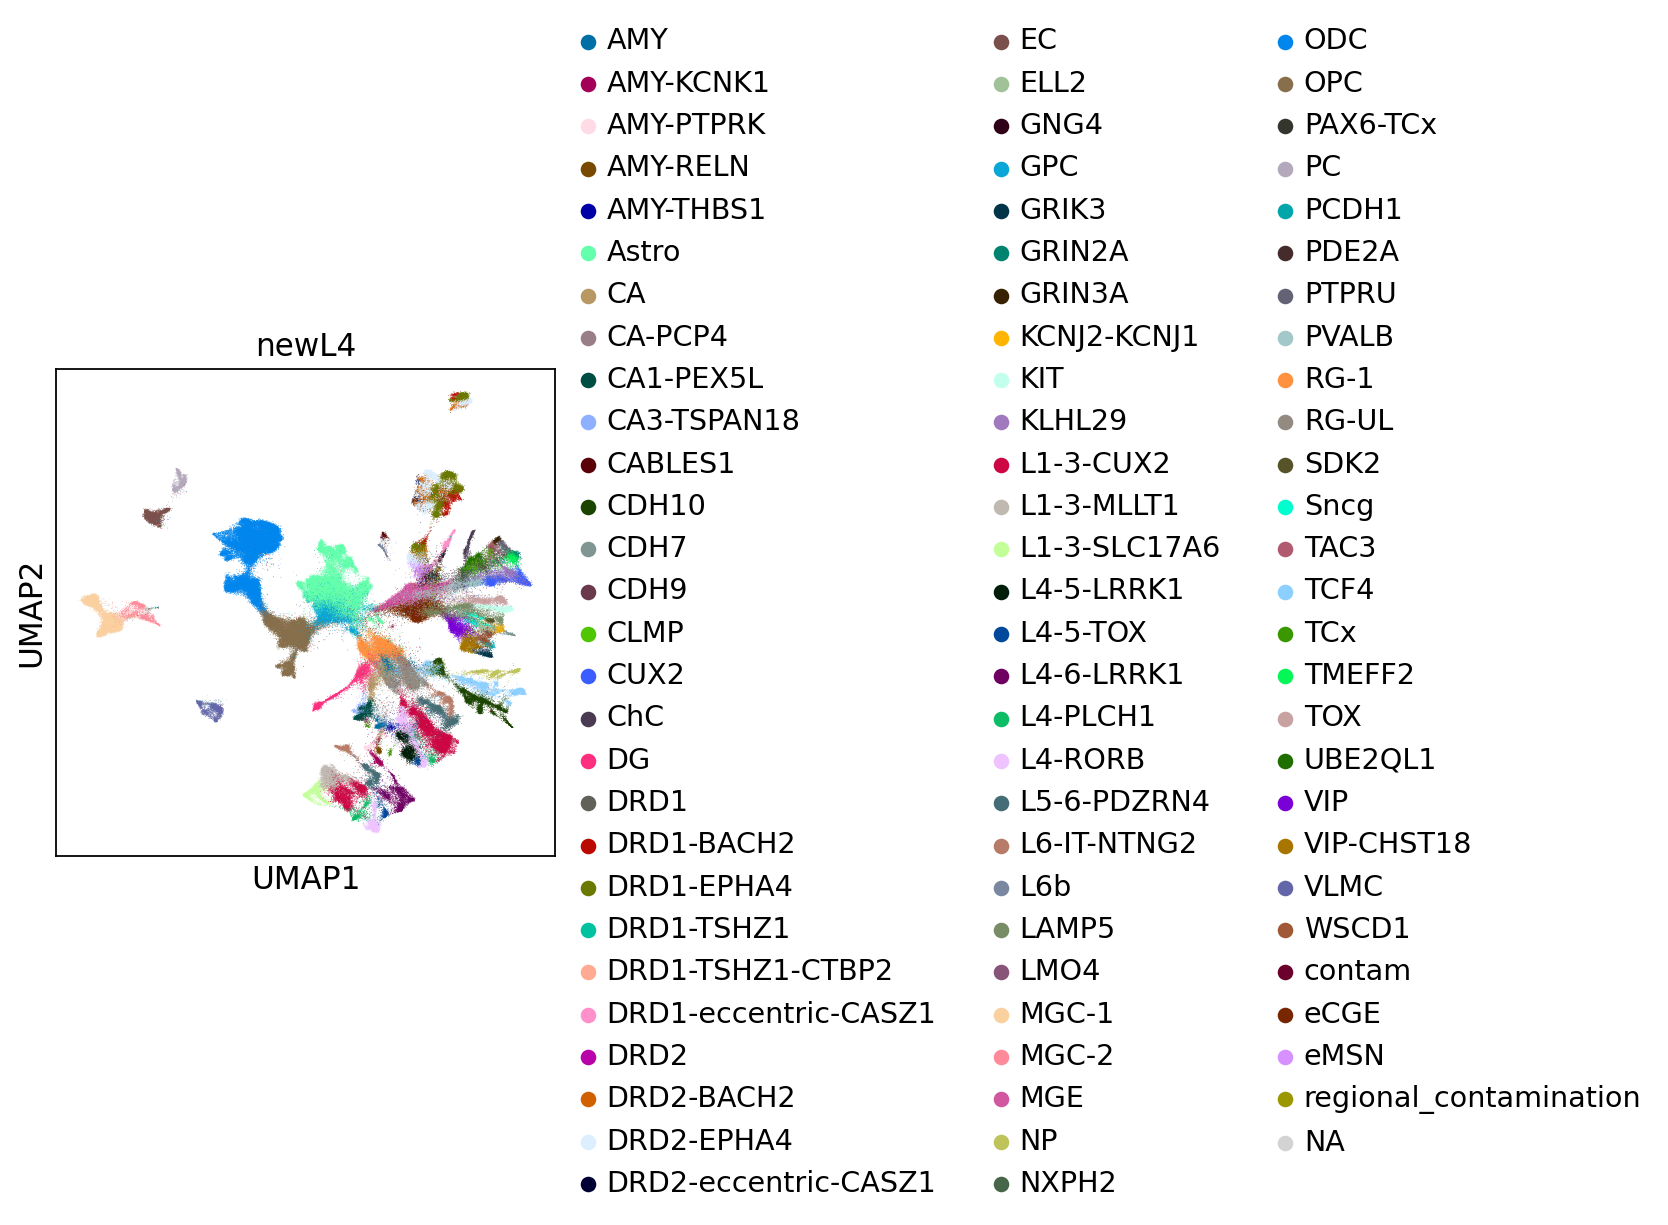

In [10]:
sc.pl.umap(adata, color='newL4',palette=sc.pl.palettes.godsnot_102[4:], groups=[i for i in adata.obs['newL4'].astype(str).unique() if i not in ['?','nan']],
          save='newL4.pdf')

In [11]:
adata.obs['merge_regions']=adata.obs['updated_region'].copy()
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('DFC','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('HIP','HIP+AMY')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('TCx','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('CCx','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('THM','Thalamus')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('Ca','Striatum')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('Pu+GP','Mixed')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('Pu','Striatum')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('GP','Globus Pallidus')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('PoCG','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('ICx','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('STR','Striatum')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('FCx','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('PoCG+ICx','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('LV','LV')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('AMY','HIP+AMY')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('FCx+LV+STR+PoCG','Mixed')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('LV+STR+ICx+TCx','Mixed')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('OFC','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('THM+Ca','Mixed')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('FI','Cortex')
adata.obs['merge_regions']=adata.obs['merge_regions'].replace('MTG','Cortex')

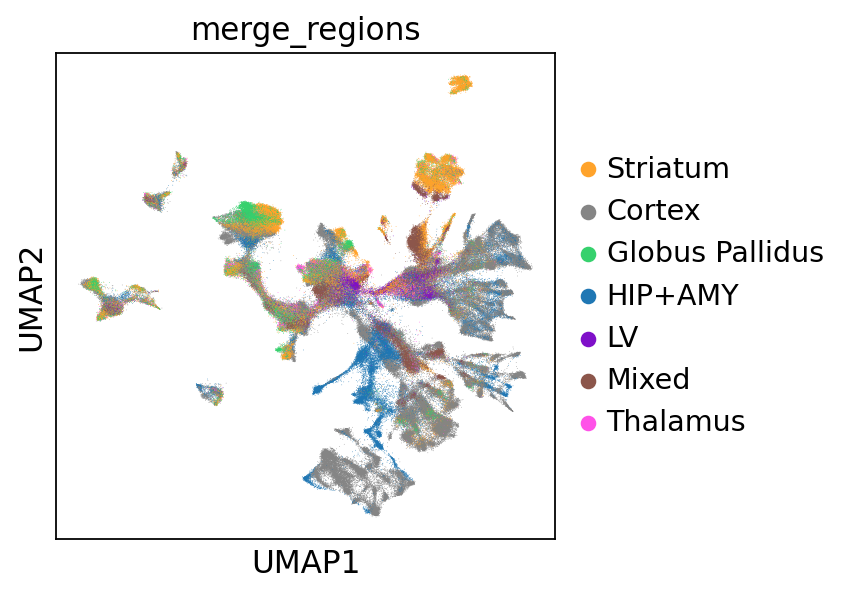

In [12]:
adata.uns['merge_regions_colors']=['#ffa32b','#858585', '#36d16d', '#1f77b4',  '#7f10c9', '#8c564b', '#ff52e8']
sc.pl.umap(adata, color='merge_regions',save='merge_region.pdf')

In [13]:
hexc=pd.DataFrame(adata.obs['merge_regions'].cat.categories)
hexc.columns=['merge_regions']
hexc=hexc.set_index('merge_regions')
hexc['hex_code']=adata.uns['merge_regions_colors']
hexc.to_csv('merge_regions_color_codes.csv')
hexc

,hex_code
merge_regions,
Striatum,#ffa32b
Cortex,#858585
Globus Pallidus,#36d16d
HIP+AMY,#1f77b4
LV,#7f10c9
Mixed,#8c564b
Thalamus,#ff52e8


In [14]:
adata.obs[['merge_regions']].to_csv('merge_regions_10132025.csv')

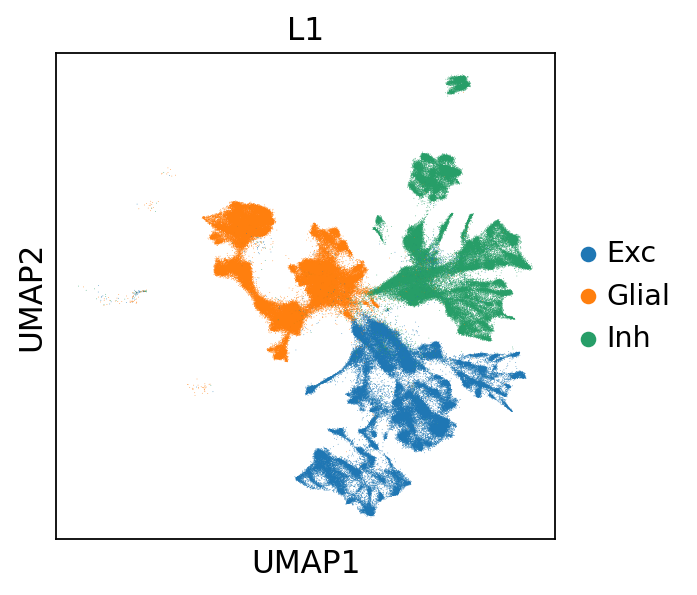

In [15]:
sc.pl.umap(adata[adata.obs['newL1']!='NN'], color='L1')